Using p range: [0.720000, 0.900000]  (N=19)


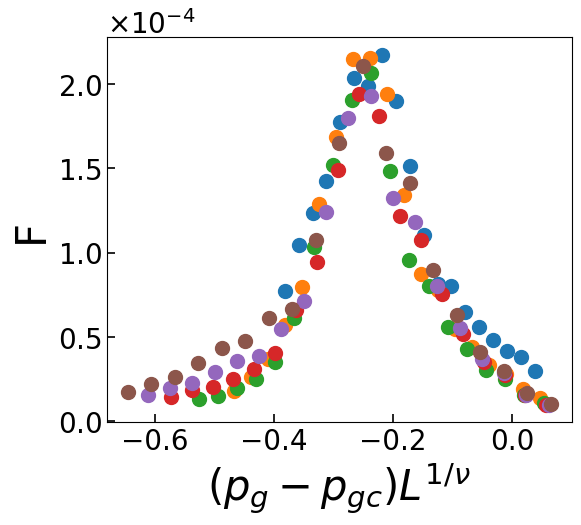


=== 分散 FSS ===
pc = 0.8835461180127383 ± 0.04969894385415566
nu = 1.7062759034647463 ± 0.38260714240090904
zeta = 3.390045265410035 ± 0.6273958239816217
S (var)  = 0.2250437083861608


In [3]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))   # 強制的に指数表記


# ======================
# 設定
# ======================
gamma = 0.5

# L と TEE キー
# L_list は FSSA のスケール長 (L) を入れる。ここでは sqrt(セル数) を使用。
L_list = [np.sqrt(18),np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE1','TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE3', 'TEE4', 'TEE5', 'TEE6']

# データファイル
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"

# カラーマップ
cmap = cm.get_cmap('gnuplot', 4)

# ======================
# p の使用範囲の指定（いずれか1つを有効に）
# ======================
# 方式A: 値で指定（例: 0.30 <= p <= 0.90）
use_by_value = True
pmin, pmax = 0.72, 0.9

# 方式B: 連続インデックスで指定（例: 5〜45 まで）
idx_slice = None  # 例: slice(5, 46)

# 方式C: 個別インデックスのリスト（例: 偶数番だけ）
idx_list = None   # 例: [0, 2, 4, 6, 8]

# ======================
# データ読み込み
# ======================
data = np.load(npz_path)
p_all = data['pg']  # 全 p
# a_mean, da_mean, a_var, da_var を先に作り、あとで列方向に同じマスクを適用
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)       # shape=(nL, nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 仮に同じ誤差を使用

# ======================
# マスク作成
# ======================
if use_by_value:
    mask = (p_all >= pmin) & (p_all <= pmax)
elif idx_slice is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[idx_slice] = True
elif idx_list is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[np.array(idx_list, dtype=int)] = True
else:
    mask = np.ones_like(p_all, dtype=bool)  # 全部使う

# 安全チェック
if not np.any(mask):
    raise ValueError("選択マスクが空です。p の範囲やインデックス指定を見直してください。")

# マスク適用（列方向＝p軸に沿って揃える）
p_use = p_all[mask]
a_mean_sel  = a_mean[:,  mask]
da_mean_sel = da_mean[:, mask]
a_var_sel   = a_var[:,   mask]
da_var_sel  = da_var[:,  mask]

print(f"Using p range: [{p_use.min():.6f}, {p_use.max():.6f}]  (N={p_use.size})")

# ======================
# 分散 FSS
# ======================
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=0.87, nu0=1.73, zeta0=3.3)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------

labels = [r"$A_h=6$", r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]

fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i],
               label=labels[i], s=100)
    

ax.yaxis.set_major_formatter(formatter)
ax.yaxis.get_offset_text().set_fontsize(20) 
ax.set_xlabel(r'$(p_g-p_{gc})L^{1/\nu}$', fontsize=30)
ax.set_ylabel('F', fontsize=30)
#ax.legend()
ax.tick_params(axis='both', which='major',
                    direction="in",    # 内向きに（物理系論文でよく使う）
                    length=6, width=1.2,
                    labelsize=20)
ax.grid(False)
#plt.title(f"TEE Variance collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("fig4_inset.png", dpi=300, bbox_inches='tight')
plt.savefig("fig4ab_X/fig4_inset_initial_X.svg", format="svg", bbox_inches="tight", transparent=True)
plt.show()
plt.close(fig)

# ======================
# 結果表示
# ======================
print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu,  "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S (var)  =", fssa.quality(xs_var, ys_var, dys_var))

Using p range: [0.720000, 0.900000]  (N=19)


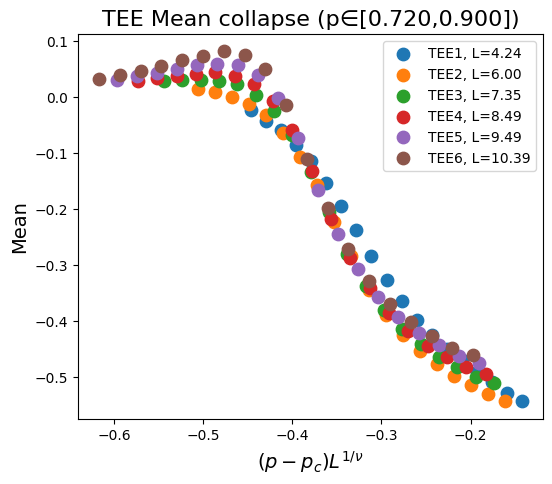

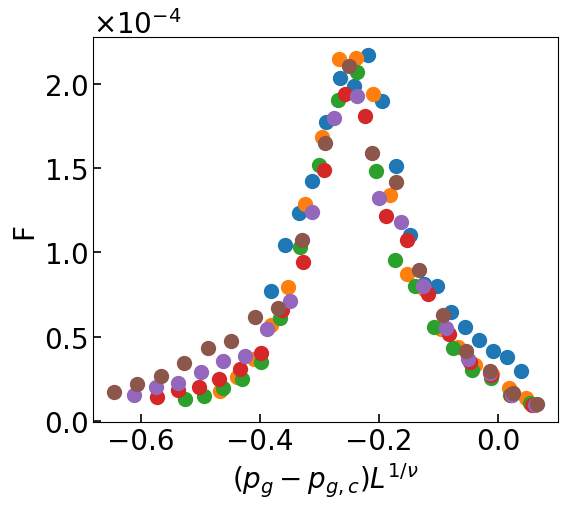

=== 平均 FSS ===
pc = 0.9844040970360879 ± 0.0025535936581012786
nu = 2.7619346253218886 ± 0.03874977302969574
zeta = 0.8227519183989942 ± 0.5025311497851833
S (mean) = 1394.6446256261497

=== 分散 FSS ===
pc = 0.8835461180127383 ± 0.04969894385415566
nu = 1.7062759034647463 ± 0.38260714240090904
zeta = 3.390045265410035 ± 0.6273958239816217
S (var)  = 0.2250437083861608


In [2]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))   # 強制的に指数表記


# ======================
# 設定
# ======================
gamma = 0.5

# L と TEE キー
# L_list は FSSA のスケール長 (L) を入れる。ここでは sqrt(セル数) を使用。
L_list = [np.sqrt(18),np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE1','TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE3', 'TEE4', 'TEE5', 'TEE6']

# データファイル
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"

# カラーマップ
cmap = cm.get_cmap('gnuplot', 4)

# ======================
# p の使用範囲の指定（いずれか1つを有効に）
# ======================
# 方式A: 値で指定（例: 0.30 <= p <= 0.90）
use_by_value = True
pmin, pmax = 0.72, 0.9

# 方式B: 連続インデックスで指定（例: 5〜45 まで）
idx_slice = None  # 例: slice(5, 46)

# 方式C: 個別インデックスのリスト（例: 偶数番だけ）
idx_list = None   # 例: [0, 2, 4, 6, 8]

# ======================
# データ読み込み
# ======================
data = np.load(npz_path)
p_all = data['pg']  # 全 p
# a_mean, da_mean, a_var, da_var を先に作り、あとで列方向に同じマスクを適用
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)       # shape=(nL, nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 仮に同じ誤差を使用

# ======================
# マスク作成
# ======================
if use_by_value:
    mask = (p_all >= pmin) & (p_all <= pmax)
elif idx_slice is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[idx_slice] = True
elif idx_list is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[np.array(idx_list, dtype=int)] = True
else:
    mask = np.ones_like(p_all, dtype=bool)  # 全部使う

# 安全チェック
if not np.any(mask):
    raise ValueError("選択マスクが空です。p の範囲やインデックス指定を見直してください。")

# マスク適用（列方向＝p軸に沿って揃える）
p_use = p_all[mask]
a_mean_sel  = a_mean[:,  mask]
da_mean_sel = da_mean[:, mask]
a_var_sel   = a_var[:,   mask]
da_var_sel  = da_var[:,  mask]

print(f"Using p range: [{p_use.min():.6f}, {p_use.max():.6f}]  (N={p_use.size})")

# ======================
# 平均値 FSS
# ======================
ret_mean = fssa.autoscale(L_list, p_use, a_mean_sel, da_mean_sel,
                          rho_c0=0.86, nu0=1.82, zeta0=2.9)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean_sel, da_mean_sel,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_mean.T[:, i], ys_mean.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean', fontsize=14)
ax.legend()
plt.title(f"TEE Mean collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 分散 FSS
# ======================
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=0.87, nu0=1.73, zeta0=3.3)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------

labels = [r"$A_h=6$", r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]

fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i],
               label=labels[i], s=100)
    

ax.yaxis.set_major_formatter(formatter)
ax.yaxis.get_offset_text().set_fontsize(20) 
ax.set_xlabel(r'$(p_g-p_{g,c})L^{1/\nu}$', fontsize=20)
ax.set_ylabel('F', fontsize=20)
#ax.legend()
ax.tick_params(axis='both', which='major',
                    direction="in",    # 内向きに（物理系論文でよく使う）
                    length=6, width=1.2,
                    labelsize=20)
ax.grid(False)
#plt.title(f"TEE Variance collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("fig4_inset.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 結果表示
# ======================
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu,  "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S (mean) =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu,  "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S (var)  =", fssa.quality(xs_var, ys_var, dys_var))